**Unsupervised Learning**

From: O'Reilly book Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow

The book is available online for free through MRU Library

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import sklearn

# Common imports
import numpy as np

# to make this notebook's output stable across runs
# np.random.seed(42)

# To plot pretty figures
%matplotlib inline
# import matplotlib as mpl
import matplotlib.pyplot as plt
# mpl.rc('axes', labelsize=14)
# mpl.rc('xtick', labelsize=12)
# mpl.rc('ytick', labelsize=12)


# Clustering

## K-Means

The K-Means algorithm is one of the fastest clustering algorithms, and also one of the simplest:
* First initialize $k$ centroids randomly: $k$ distinct instances are chosen randomly from the dataset and the centroids are placed at their locations.
* Repeat until convergence (i.e., until the centroids stop moving):
    * Assign each instance to the closest centroid.
    * Update the centroids to be the mean of the instances that are assigned to them.

### Small Dataset for Manual Clustering

In class, we clustered these points manually.

In [2]:
X =[[185,72],
[170,56],
[168,60],
[179,68],
[182,72],
[188,77]]

k = 2

In [3]:
from sklearn.cluster import KMeans

In [4]:
kmeans = KMeans(n_clusters=k, random_state=42)


In [5]:
y_pred = kmeans.fit_predict(X)
y_pred

array([1, 0, 0, 1, 1, 1])

**Effect of initial points**

When the centroids are  initialized randomly, the algorithm runs iterations to gradually improve the centroids. One major problem is that if you run K-Means multiple times (or with different random seeds), it can converge to different solutions. To see this, below two algorithms with same number of iterations but different inital points are shown:

In [6]:
kmeans_c1 = KMeans(n_clusters=2, init=([179,68], [188,77]), n_init=1, max_iter=1, random_state=0)
y_pred_c1 = kmeans_c1.fit_predict(X)
y_pred_c1

array([1, 0, 0, 0, 1, 1])

In [7]:
kmeans_c2 = KMeans(n_clusters=2, init=([170,56], [182,72]), n_init=1, max_iter=1, random_state=0)
y_pred_c2 = kmeans_c2.fit_predict(X)
y_pred_c2

array([1, 0, 0, 1, 1, 1])

**Effect of iterations**

Let's compare the results after the first and second iteration of k-means.

In [8]:
#n_init: Number of times the k-means algorithm is run with different centroid seeds.

kmeans_iter1 = KMeans(n_clusters=2, init=([179,68], [188,77]), n_init=1, max_iter=1, random_state=0)
y_pred_iter1 = kmeans_iter1.fit_predict(X)
y_pred_iter1

array([1, 0, 0, 0, 1, 1])

In [9]:
kmeans_iter2 = KMeans(n_clusters=2, init=([179,68], [188,77]), n_init=1, max_iter=3, random_state=0)
y_pred_iter2 = kmeans_iter2.fit_predict(X)
y_pred_iter2

array([1, 0, 0, 1, 1, 1])

In [10]:
print(kmeans_iter1.inertia_)
print(kmeans_iter2.inertia_)

225.6875
95.75


In [11]:
from sklearn.metrics import silhouette_score

In [12]:
print(silhouette_score(X, kmeans_iter1.labels_))
print(silhouette_score(X, kmeans_iter2.labels_))

0.4670191237582339
0.6884230657024594


### Clustering Using Scikit Learn Library on larger dataset

Let's start by generating some blobs of data:

In [13]:
from sklearn.datasets import make_blobs

In [41]:
blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  1.8],
     [-2.8,  2.8],
     [-2.8,  1.3]])

#The standard deviation of each cluster, 0.4 widely separated within the cluster, 0.1 tight cluster points
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

In [43]:
#X contains the data points return from the synthetic data. y represents cluster of each point
X, y = make_blobs(n_samples=2000, centers=blob_centers,cluster_std=blob_std, random_state=7)
X, y

(array([[-2.69823941,  1.3454702 ],
        [-2.87459835,  1.8097575 ],
        [ 0.96077126,  1.17046777],
        ...,
        [-2.80303543,  2.72948115],
        [ 0.24057359,  2.40103109],
        [-2.63807768,  1.95621065]]),
 array([4, 2, 0, ..., 3, 0, 2]))

Now let's plot them:

In [47]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

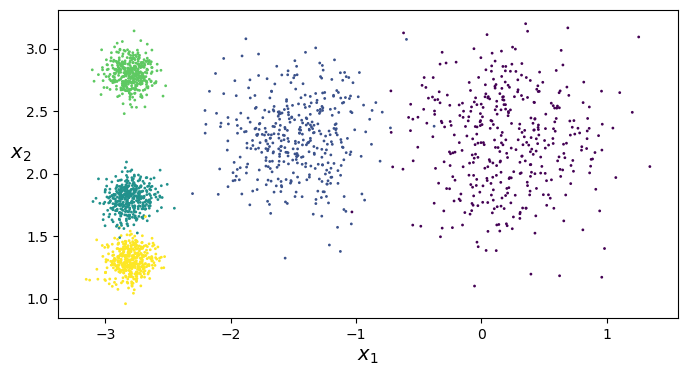

In [48]:
plt.figure(figsize=(8, 4))
plot_clusters(X, y)
plt.show()

**Fit and predict**

Let's train a K-Means clusterer on this dataset.

In [74]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
print("Clusters from KMeans", y_pred)

Clusters from KMeans [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 2 2 0 2 0 2 2 0 2 0 2 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 0 2 2 2 0 2 2 2 2 2 0 2 2 4 0 3 4 4 3 2 3 4 3 4
 4 4 0 4 4 4 3 3 0 4 0 3 0 4 3 0 0 4 3 3 3 4 0 0 3 4 4 0 4 4 4 0 4 4 4 0 4
 4 0]


And the following 5 _centroids_ (i.e., cluster centers) were estimated:

In [19]:
kmeans.cluster_centers_

array([[-0.066884  ,  2.10378803],
       [-2.79290307,  2.79641063],
       [-2.80214068,  1.55162671],
       [-1.47468607,  2.28399066],
       [ 0.47042841,  2.41380533]])

Note that the `KMeans` instance preserves the labels of the instances it was trained on. Somewhat confusingly (in clustering the dataset is not labeled), in this context, the _label_ of an instance is the index of the cluster that instance gets assigned to:

Of course, we can predict the labels of new instances:

In [20]:
#Unseen data points are assigned a cluster using the trained KMeans
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 4, 1, 1])

**Hard Clustering _vs_ Soft Clustering**

Rather than arbitrarily choosing the closest cluster for each instance, which is called _hard clustering_, it might be better measure the distance of each instance to all 5 centroids. This is what the `transform()` method does (_soft clustering_):

In [62]:
#Soft clustering for the new data points. Computing how far each point from the cluster centers
kmeans.transform(X_new)

array([[0.12347236, 2.9042344 , 2.83778629, 1.50178217, 0.62652832],
       [3.06863967, 5.84739223, 5.81943941, 4.48368889, 2.56319474],
       [3.06697984, 0.29040966, 1.4618254 , 1.685008  , 3.51958769],
       [2.95975563, 0.36159148, 0.96879317, 1.54053323, 3.47149865]])

**Cluster Evaluation**

To select the best model, we will need a way to evaluate a K-Mean model's performance. Unfortunately, clustering is an unsupervised task, so we do not have the targets. But at least we can measure the distance between each instance and its centroid. This is the idea behind the _inertia_ metric:

In [22]:
kmeans.inertia_

224.0743312251571

#### Finding the optimal number of clusters

What if the number of clusters was set to a lower or greater value than 5?

In [24]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, random_state=42)

kmeans_k3.fit(X)
kmeans_k8.fit(X)

KMeans(random_state=42)

What about their inertias?

In [25]:
print(kmeans_k3.inertia_)
print(kmeans_k8.inertia_)

653.2167190021554
127.13141880461835


We cannot simply take the value of $k$ that minimizes the inertia, since it keeps getting lower as we increase $k$. Indeed, the more clusters there are, the closer each instance will be to its closest centroid, and therefore the lower the inertia will be. However, we can plot the inertia as a function of $k$ and analyze the resulting curve:

In [26]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

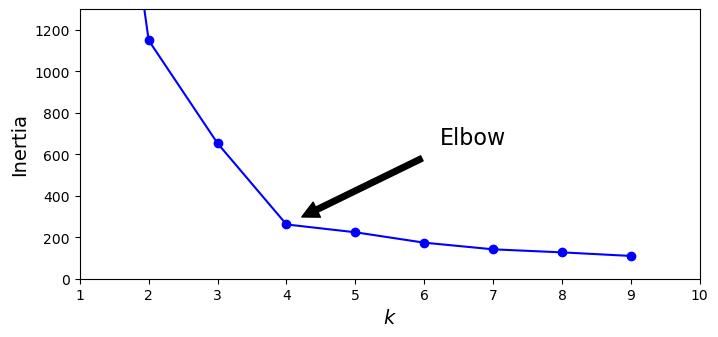

In [67]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(4, inertias[3]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 10, 0, 1300])
plt.show()

As you can see, there is an elbow at $k=4$, which means that less clusters than that would be bad, and more clusters would not help much and might cut clusters in half. So $k=4$ is a pretty good choice.

Another approach is to look at the _silhouette score_, which is the mean _silhouette coefficient_ over all the instances. An instance's silhouette coefficient is equal to $(b - a)/\max(a, b)$ where $a$ is the mean distance to the other instances in the same cluster (it is the _mean intra-cluster distance_), and $b$ is the _mean nearest-cluster distance_, that is the mean distance to the instances of the next closest cluster (defined as the one that minimizes $b$, excluding the instance's own cluster). The silhouette coefficient can vary between -1 and +1: a coefficient close to +1 means that the instance is well inside its own cluster and far from other clusters, while a coefficient close to 0 means that it is close to a cluster boundary, and finally a coefficient close to -1 means that the instance may have been assigned to the wrong cluster.

Let's plot the silhouette score as a function of $k$:

In [28]:
from sklearn.metrics import silhouette_score

In [29]:
silhouette_score(X, kmeans.labels_)

0.6267891051050735

In [30]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

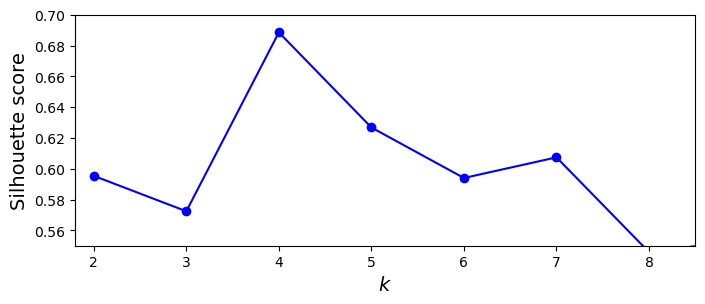

In [31]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.show()

As you can see, this visualization is much richer than the previous one: in particular, although it confirms that $k=4$ is a very good choice, but it also underlines the fact that $k=5$ is quite good as well.

## iris Data




In [58]:
from sklearn.datasets import load_iris

In [59]:
data = load_iris()
X = data.data
y = data.target
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [73]:
print(X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


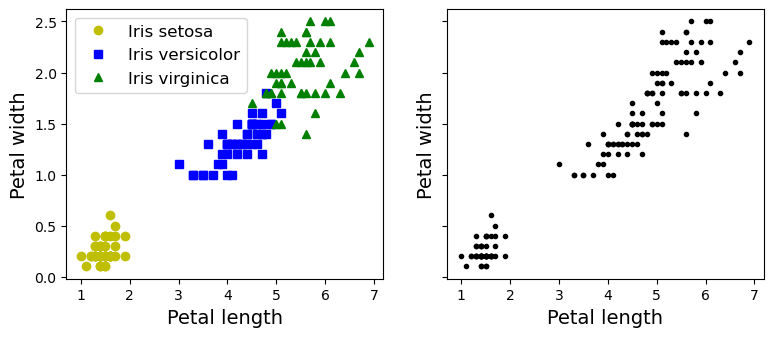

In [35]:
plt.figure(figsize=(9, 3.5))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(fontsize=12)

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.tick_params(labelleft=False)

plt.show()

In [36]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)

In [37]:
y_pred = kmeans.fit_predict(X)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2])

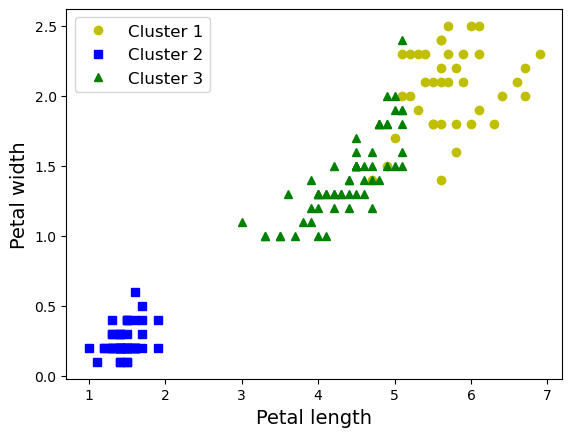

In [39]:
plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.show()